# 04 - Modelling

Compare four classifiers on the engineered features, tune the best one, and save it for the app.

* every model runs inside a pipeline `preprocessor -> SMOTE -> classifier`, so the scaler,
  the encoder and the synthetic churners are all produced from the training folds only;
* every model is scored with 5-fold stratified cross-validation on accuracy, precision, recall,
  F1 and ROC-AUC;
* the best family is tuned with `RandomizedSearchCV` on the training split;
* the held-out 20% from notebook 03 is used exactly once, at the end.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import TARGET
from src.metrics import (
    classification_metrics,
    metrics_table,
    plot_confusion,
    plot_feature_importance,
    plot_precision_recall,
    plot_roc_curves,
    plot_threshold_sweep,
)
from src.features import feature_names
from src.train import RANDOM_STATE, compare_models, get_models, make_cv, make_pipeline, param_grids, tune_model

FIG = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports"
PROCESSED = PROJECT_ROOT / "data" / "processed"
sns.set_theme(style="whitegrid")

train = pd.read_csv(PROCESSED / "train.csv")
test = pd.read_csv(PROCESSED / "test.csv")
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]
print("train", X_train.shape, "churn rate", round(y_train.mean(), 4))
print("test ", X_test.shape, "churn rate", round(y_test.mean(), 4))

train (5634, 23) churn rate 0.2654
test  (1409, 23) churn rate 0.2654


## Handling the imbalance

SMOTE synthesises new minority-class rows by interpolating between neighbouring churners. It
sits *inside* the pipeline as a sampler step, which means it only runs during `fit`: each CV
fold resamples its own training portion, the validation fold stays real, and the test set is
never resampled. Fitting one pipeline on the full training split shows what the classifier
actually sees.

In [2]:
demo = make_pipeline(get_models()["Logistic Regression"])
X_enc = demo.named_steps["prep"].fit_transform(X_train)
X_res, y_res = demo.named_steps["smote"].fit_resample(X_enc, y_train)
print("training rows before SMOTE:", y_train.value_counts().to_dict())
print("training rows after SMOTE :", y_res.value_counts().to_dict())
print("test rows (untouched)     :", y_test.value_counts().to_dict())

training rows before SMOTE: {0: 4139, 1: 1495}
training rows after SMOTE : {0: 4139, 1: 4139}
test rows (untouched)     : {0: 1035, 1: 374}


## Cross-validated comparison

In [3]:
models = get_models()
cv = make_cv(5)
comparison = compare_models(models, X_train, y_train, cv=cv)
comparison.round(4)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_s
model,,,,,,,,,,,
Logistic Regression,0.7691,0.0218,0.5512,0.0336,0.7037,0.0372,0.6181,0.0343,0.8346,0.0117,7.2275
Random Forest,0.7772,0.0085,0.5626,0.0112,0.7184,0.0432,0.6307,0.0226,0.8395,0.0098,1.4201
XGBoost,0.7767,0.0137,0.5636,0.0211,0.7010,0.0383,0.6247,0.0265,0.8369,0.0105,0.8954
LightGBM,0.7835,0.0095,0.5788,0.0150,0.6749,0.0335,0.6229,0.0211,0.8344,0.0101,0.9704


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.7691,0.5512,0.7037,0.6181,0.8346
Random Forest,0.7772,0.5626,0.7184,0.6307,0.8395
XGBoost,0.7767,0.5636,0.7010,0.6247,0.8369
LightGBM,0.7835,0.5788,0.6749,0.6229,0.8344


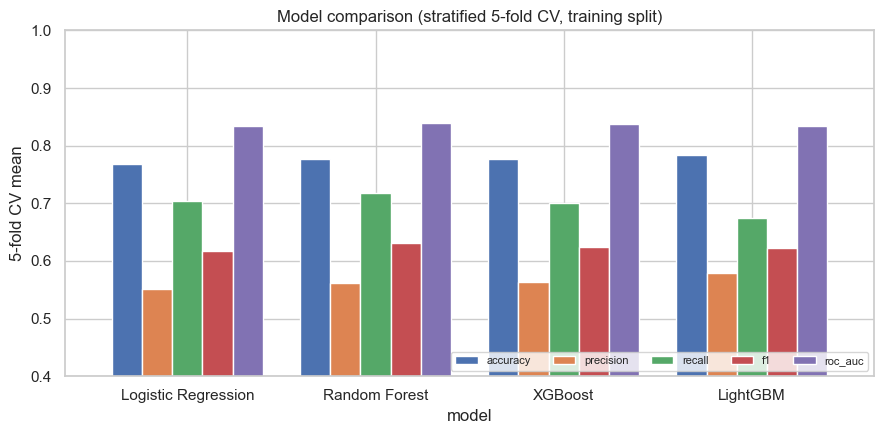

In [4]:
means = comparison[[f"{m}_mean" for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]]]
means.columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
means.round(4).to_csv(REPORTS / "model_comparison.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
means.plot.bar(ax=ax, width=0.8)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("5-fold CV mean")
ax.set_title("Model comparison (stratified 5-fold CV, training split)")
ax.legend(loc="lower right", ncol=5, fontsize=8)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "12_model_comparison.png")
means.round(4)

In [5]:
best_name = comparison["roc_auc_mean"].idxmax()
print("best by CV ROC-AUC:", best_name)

best by CV ROC-AUC: Random Forest


The four families are close: ROC-AUC sits between 0.834 and 0.840 and F1 between 0.62 and
0.63, with fold-to-fold standard deviations of about 0.01, so no model is clearly ahead of the
others. Random Forest edges the ranking metric (0.8395) and also has the best recall, so it goes
forward to tuning. The 77-78% accuracy looks worse than the 73% a "nobody churns" model would
score only until you look at recall: these pipelines catch ~70% of churners, the trivial model
catches none.

## Tuning the best model

Random search over the grid in `src/train.py`, scored by ROC-AUC under the same 5-fold CV on
the training split. The winner is refitted on the whole training split. The test rows play no
part in choosing the parameters.

In [6]:
best_pipeline, search_log = tune_model(
    models[best_name], param_grids()[best_name], X_train, y_train, cv=cv, n_iter=20
)
search_log.head(10).round(4)

,mean_test_score,std_test_score,mean_fit_time,n_estimators,min_samples_leaf,max_features,max_depth
0,0.8439,0.0102,0.5284,200,2,0.3,6
1,0.8437,0.0102,1.2015,400,4,0.3,6
2,0.8437,0.0102,1.0934,400,2,0.3,6
3,0.8433,0.0104,0.5769,200,8,sqrt,8
4,0.8432,0.0100,0.4955,200,4,sqrt,8
5,0.8431,0.0092,2.2209,600,4,0.3,8
6,0.8428,0.0094,0.7444,200,2,0.3,8
7,0.8425,0.0096,0.8896,200,1,0.5,6
8,0.8420,0.0094,0.5733,200,4,sqrt,10
9,0.8417,0.0096,1.0753,200,8,0.5,8


In [7]:
best_params = {k.replace("clf__", ""): v for k, v in best_pipeline.get_params().items() if k in param_grids()[best_name]}
best_params

{'max_depth': 6,
 'max_features': 0.3,
 'min_samples_leaf': 2,
 'n_estimators': 200}

## Results on the held-out split

One pass over the test rows: the four baseline pipelines refitted on the full training split,
plus the tuned one.

In [8]:
probas = {}
results = {}
for name, model in models.items():
    pipeline = make_pipeline(model).fit(X_train, y_train)
    proba = pipeline.predict_proba(X_test)[:, 1]
    probas[name] = proba
    results[name] = classification_metrics(y_test, (proba >= 0.5).astype(int), proba)

tuned_proba = best_pipeline.predict_proba(X_test)[:, 1]
tuned_name = f"{best_name} (tuned)"
probas[tuned_name] = tuned_proba
results[tuned_name] = classification_metrics(y_test, (tuned_proba >= 0.5).astype(int), tuned_proba)

table = metrics_table(results)
table.to_csv(REPORTS / "test_metrics.csv")
table

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.7679,0.5493,0.7005,0.6157,0.8344,0.6336
Random Forest,0.7693,0.5499,0.7219,0.6243,0.8381,0.6376
XGBoost,0.7693,0.5520,0.6952,0.6154,0.8327,0.6427
LightGBM,0.7835,0.5762,0.6979,0.6312,0.8329,0.6389
Random Forest (tuned),0.7573,0.5288,0.7861,0.6323,0.8424,0.6509


The test numbers land within a fold's standard deviation of the CV means, which is what a
properly held-out split should look like. Tuning buys the Random Forest about +0.004 ROC-AUC and
a shallower, more regularised forest (`max_depth=6`, `max_features=0.3`) that trades some
precision for recall: at the default threshold it finds 79% of the churners in the test set at a
precision of 53%.

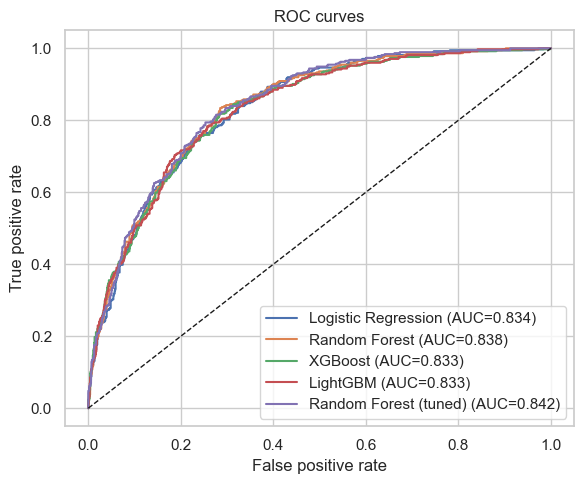

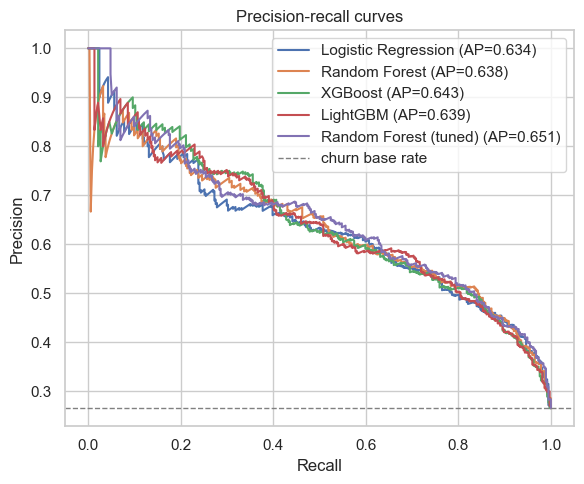

In [9]:
plot_roc_curves(probas, y_test, FIG / "13_roc_curves.png")
plot_precision_recall(probas, y_test, FIG / "14_pr_curves.png");

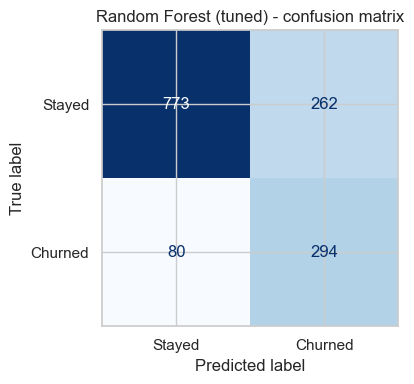

In [10]:
plot_confusion(y_test, (tuned_proba >= 0.5).astype(int), f"{tuned_name} - confusion matrix", FIG / "15_confusion_matrix.png");

## Choosing a decision threshold

The default 0.5 cut-off is not necessarily the right one for a retention campaign. The sweep
below shows the precision/recall trade-off; the app exposes the threshold as a slider so the
business can pick the point that matches their outreach capacity.

,threshold,precision,recall,f1
0,0.10,0.337,0.989,0.502
1,0.15,0.357,0.984,0.523
2,0.20,0.380,0.968,0.546
3,0.25,0.404,0.949,0.567
4,0.30,0.427,0.925,0.584
5,0.35,0.441,0.896,0.591
6,0.40,0.471,0.861,0.609
7,0.45,0.504,0.834,0.628
8,0.50,0.529,0.786,0.632
9,0.55,0.545,0.738,0.627


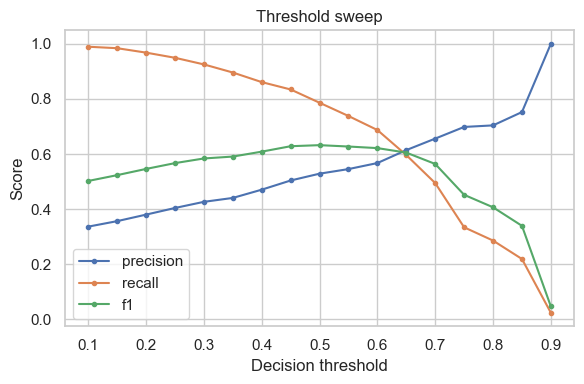

In [11]:
sweep = plot_threshold_sweep(y_test, tuned_proba, FIG / "16_threshold_sweep.png")
sweep.round(3)

F1 peaks right around 0.5 for this model, so I keep 0.5 as the default. Moving the cut-off to
0.35 lifts recall to ~90% for a precision of ~44% - roughly one genuine churner for every
two customers contacted - which is the kind of trade a retention team with spare capacity would
happily make, and the reason the threshold is a slider in the app rather than a constant.

## Feature importance

The model's own importance measure, as a first look. Notebook 05 does this properly with SHAP.

Contract_Two year                 0.1816
tenure                            0.1648
InternetService_Fiber optic       0.1061
Contract_One year                 0.0879
MonthlyCharges                    0.0577
TotalCharges                      0.0554
OnlineSecurity_Yes                0.0506
avg_monthly_charge                0.0497
PaymentMethod_Electronic check    0.0444
InternetService_No                0.0418
tenure_group_49-72                0.0333
Dependents_Yes                    0.0246
dtype: float64

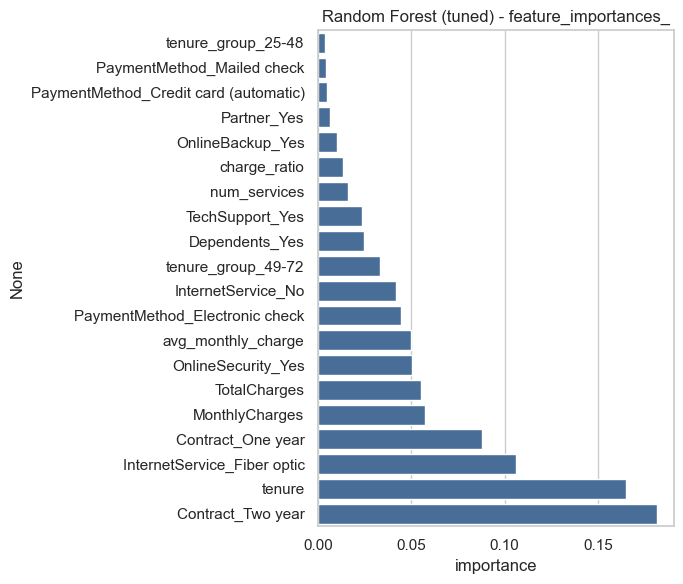

In [12]:
clf = best_pipeline.named_steps["clf"]
columns = feature_names(best_pipeline.named_steps["prep"])
if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=columns)
    kind = "feature_importances_"
else:
    importances = pd.Series(np.abs(clf.coef_[0]), index=columns)
    kind = "|coef|"
plot_feature_importance(importances, f"{tuned_name} - {kind}", FIG / "17_feature_importance.png")
importances.sort_values(ascending=False).head(12).round(4)

## Save the pipeline

The whole pipeline (preprocessor + model) is saved as one artefact, so the app scores raw
customer rows with exactly the encoding the model was trained on.

In [13]:
joblib.dump(best_pipeline, MODELS / "churn_pipeline.joblib")

summary = {
    "model": best_name,
    "params": {k: (v.item() if hasattr(v, "item") else v) for k, v in best_params.items()},
    "threshold": 0.5,
    "cv_comparison": means.round(4).to_dict(orient="index"),
    "tuned_cv_roc_auc": round(float(search_log.loc[0, "mean_test_score"]), 4),
    "test_metrics": table.to_dict(orient="index"),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}
with open(REPORTS / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary["test_metrics"][tuned_name], indent=2))

{
  "accuracy": 0.7573,
  "precision": 0.5288,
  "recall": 0.7861,
  "f1": 0.6323,
  "roc_auc": 0.8424,
  "pr_auc": 0.6509
}
